In [ ]:
import os
import yaml
import math
import numpy as np
import pandas as pd
from box import Box
import matplotlib.pyplot as plt
from azureml.core import Workspace, Dataset
import torch  # For tensors and DataLoader
import torch.nn as nn
from torch.utils.data import DataLoader  # For creating and loading datasets
import rasterio as rio  # For reading geospatial image files
import torchvision.transforms as v2  # For normalization
from src.module import ClayMAEModule

# Define Azure ML workspace details
subscription_id = '9ead393f-4604-4166-b88b-9e7f2ca53d62'
resource_group = 'pdsppoc2_rg_data_sandbox_module'
workspace_name = 'pdsppoc2_data_sandbox'

# Connect to the Azure ML workspace
workspace = Workspace(subscription_id, resource_group, workspace_name)

# Get the dataset by name
dataset = Dataset.get_by_name(workspace, name='geofingerprinting')

# Mount the dataset to a local directory
mount_context = dataset.mount(target_path='./mounted_data', overwrite=False)

# Start the mount context
mount_context.start()

print("Dataset mounted at:", mount_context.mount_point)

# Remember to stop the mount context when done
# mount_context.stop()

# Paths to the folders
geofingerprinting_path = f"{ mount_context.mount_point}/geofingerprinting"
ground_truth_path = os.path.join(geofingerprinting_path, "ground_truth")
patches_path = os.path.join(geofingerprinting_path, "patches")

Dataset mounted at: /tmp/tmprg7ix6vz


In [19]:
# Getting all the file names in the ground truth directory
if os.path.exists(ground_truth_path):
    num_files = [f for f in os.listdir(ground_truth_path) 
                 if f.endswith('.npy') and os.path.isfile(os.path.join(ground_truth_path, f))]
    # Save filenames to CSV
    df = pd.DataFrame(num_files, columns=['filename'])
    df.to_csv('ground_truth_files_name.csv', index=False)
    print(f"Number of .npy files in 'ground_truth_path': {len(num_files)}")
else:
    print("'ground_truth_path' folder does not exist.")

Number of .npy files in 'ground_truth_path': 103356


In [20]:
# Load filenames from CSV 
df = pd.read_csv('ground_truth_files_name.csv')
num_files = df['filename'].tolist()

In [21]:
df.head()

,filename
0,HP6209SW_0.npy
1,HP6209SW_1.npy
2,HP6209SW_10.npy
3,HP6209SW_11.npy
4,HP6209SW_12.npy


# Example plot of the data in the mount

In [22]:
# Compute the mask matrix for our building boundaries, fine-tuning for looking at roof material specifically
def compute_mask_matrix(orig, masked, PATCH_SIZE=14, THRESHOLD=0.5):
    C, H, W = orig.shape
    ph = PATCH_SIZE
    np_h, np_w = H//ph, W//ph

    diff = np.any(orig != masked, axis=0)  # pixel-level mask
    mask_list = []
    for i in range(np_h):
      for j in range(np_w):
        patch = diff[i*ph:(i+1)*ph, j*ph:(j+1)*ph]
        frac = patch.mean()
        mask_list.append(0.0 if frac > THRESHOLD else 1.0)
    return torch.tensor(mask_list)

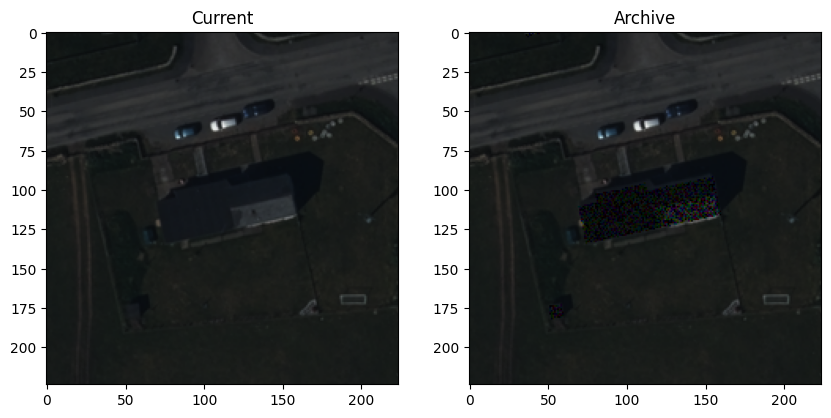

Shape of ground truth: (4, 224, 224)
Shape of patch: (4, 224, 224)


In [23]:
def plot_patch(current, archive):
    # Move channels to the last axis (from (4, 224, 224) to (224, 224, 4))
    current = np.moveaxis(current, 0, -1)
    archive = np.moveaxis(archive, 0, -1)
    
    # Plot the first three channels (RGB)
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(np.uint8(current[:, :, :3] / 255))  # Normalize and plot RGB for current
    ax[0].set_title('Current')
    ax[1].imshow(np.uint8(archive[:, :, :3] / 255))  # Normalize and plot RGB for archive
    ax[1].set_title('Archive')
    plt.show()

gt = np.load(os.path.join(ground_truth_path, num_files[3]))
ptch = np.load(os.path.join(patches_path, num_files[3]))

plot_patch(gt, ptch)
print(f'Shape of ground truth: {gt.shape}')
print(f'Shape of patch: {ptch.shape}')

In [24]:
mask_matrix = compute_mask_matrix(gt, ptch)
print("Mask matrix shape:", mask_matrix.shape)  # Should be matrix shape: torch.Size([256])

Mask matrix shape: torch.Size([256])


# Next we define a class for data preprocessing 

The RoofFineTuneDataset is a custom PyTorch dataset class designed to preprocess and load geospatial data for fine-tuning a machine learning model. It is tailored for tasks involving satellite or aerial imagery, such as roof segmentation, change detection, or other geospatial analyses.

Key Features of RoofFineTuneDataset:
Input Data:

Takes paths to original and masked image files (orig_paths and mask_paths).
Reads geospatial image data using rasterio.
Spectral Normalization:

Normalizes the pixel values of the images using mean and standard deviation values from a metadata YAML file (metadata_yaml).
This ensures that the input data is scaled consistently across different bands.
Placeholder Features:

Includes placeholder tensors for time and latitude/longitude (latlon) information, which can be used for temporal and spatial modeling.
These placeholders are initialized as zero tensors.
Additional Features:

Includes ground sampling distance (GSD) and wavelengths for each band, which are extracted from the metadata YAML file.
Patch Masking:

Computes a mask matrix to identify differences between the original and masked images.
This is useful for tasks like change detection or masked image reconstruction.
Output:

Returns a dictionary containing:
Normalized image pixels.
Mask matrix.
Placeholder time and latlon features.
GSD and wavelength information.

In [25]:
class RoofFineTuneDataset(Dataset):
    def __init__(self, orig_paths, mask_paths, metadata_yaml):
        self.orig_paths = orig_paths
        self.mask_paths = mask_paths
        self.N = len(orig_paths)

        # Modify normalization to handle scale properly
        md = Box(yaml.safe_load(open(metadata_yaml)))
        band_names = md.os_rgb_i.band_order
        
        # Scale means and stds to match input range
        mean = [md.os_rgb_i.bands.mean[band] * 255 for band in band_names]
        std = [md.os_rgb_i.bands.std[band] * 255 for band in band_names]
        
        self.normalize = v2.Compose([
            v2.ConvertImageDtype(torch.float32),
            v2.Normalize(mean=mean, std=std)
        ])

        # Placeholder values for time and latlon
        self.time = torch.zeros((self.N, 4), dtype=torch.float32)
        self.latlon = torch.zeros((self.N, 4), dtype=torch.float32)

        # GSD & wavelengths
        self.gsd = torch.tensor([0.25] * self.N, dtype=torch.float32)
        waves = [md.os_rgb_i.bands.wavelength[band] for band in band_names]
        self.waves = torch.tensor([waves] * self.N, dtype=torch.float32)

         # Add validation function
        self.validate_input_range = lambda x, name: self._validate_input_range(x, name)
    
    
    def __len__(self):
        return self.N
    
    # Add this to RoofFineTuneDataset.__getitem__
    def validate_input_range(self, tensor, name):
        min_val = tensor.min().item()
        max_val = tensor.max().item()
        if min_val < 0 or max_val > 255:
            raise ValueError(f"{name} values outside expected range [0,255]: min={min_val}, max={max_val}")

    def __getitem__(self, idx):
        # Ensure pixels are in correct range before normalization
        orig = np.load(self.orig_paths[idx]).astype(np.float32)  # [0,255] range
        masked = np.load(self.mask_paths[idx]).astype(np.float32)

        # Compute patch-mask vector
        mask_matrix = compute_mask_matrix(orig, masked)  # Shape (196,)

        # Normalize spectrally
        pix = torch.from_numpy(orig[np.newaxis, ...])  # (1, 4, 224, 224)
        pix = self.normalize(pix).squeeze(0)  # → (4, 224, 224)

        return {
            "pixels": pix,                # (4, 224, 224)
            "mask_matrix": mask_matrix,   # (196,)
            "time": self.time[idx],       # (4,) Placeholder
            "latlon": self.latlon[idx],   # (4,) Placeholder
            "gsd": self.gsd[idx],         # ()
            "waves": self.waves[idx],     # (4,)
        }

In [26]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PATCH_SIZE=14
THRESHOLD=0.5
BATCH_SIZE = 10
NUM_WORKERS = min(os.cpu_count(), 8)  # Use up to 8 workers
PIN_MEMORY = True if DEVICE == "cuda" else False
LR = 1e-3

# Get the first 10 file paths for both ground truth and patches to test the implementation
first_10_files = num_files[0:10]  # Get first 10 filenames from your list
# Create full paths for both original and masked images
orig_first_10 = [os.path.join(ground_truth_path, f) for f in first_10_files]
mask_first_10 = [os.path.join(patches_path, f) for f in first_10_files]

# dataset = RoofFineTuneDataset(
#     ground_truth_path, 
#     patches_path, 
#     metadata_yaml="configs/metadata.yaml")

# Initialize dataset with only 10 files
small_dataset = RoofFineTuneDataset(
    orig_paths=orig_first_10,
    mask_paths=mask_first_10,
    metadata_yaml="configs/metadata.yaml"
)

# DataLoader with enhanced settings
loader = DataLoader(
    small_dataset, 
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=True  # Keep workers alive between epochs
)

/anaconda/envs/claymodel/lib/python3.11/site-packages/torch/cuda/__init__.py:654: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [27]:
# Test validation with small_dataset instead of dataset
try:
    first_item = small_dataset[0]
    # Convert to float tensors for min/max operations
    pixel_tensor = first_item['pixels']
    print("Validation passed for first item")
    print(f"Original image range: [{pixel_tensor.min().item():.2f}, {pixel_tensor.max().item():.2f}]")
    
    # Additional validation info
    print("\nValidation Details:")
    print(f"Pixel tensor shape: {pixel_tensor.shape}")
    print(f"Pixel tensor dtype: {pixel_tensor.dtype}")
    print(f"Number of non-zero elements: {torch.count_nonzero(pixel_tensor)}")
except ValueError as e:
    print(f"Validation failed: {e}")
except Exception as e:
    print(f"Unexpected error during validation: {str(e)}")

Validation passed for first item
Original image range: [1529.95, 24153.38]

Validation Details:
Pixel tensor shape: torch.Size([4, 224, 224])
Pixel tensor dtype: torch.float32
Number of non-zero elements: 200704


In [28]:
model = ClayMAEModule.load_from_checkpoint(
    checkpoint_path="checkpoints/clay-v1.5.ckpt",
    model_size="large",
    metadata_path="configs/metadata.yaml",
    mask_ratio=1.0, # mask_ratio=1.0 disables random masks; we'll supply our own mask_matrix
    shuffle=False,
).to(DEVICE)
model.train()

mse = nn.MSELoss(reduction="none")

The following code is to do the training of the Clay model:
- **Forward pass**
    - `encoder` takes your normalized pixels, time/latlon/gsd/waves plus the `mask_matrix`,
    - returns latent patch embeddings for both masked and unmasked regions.
    - `decoder` re-projects those back into full 224×224 images.
- **Loss construction**
    - We upsample the 196-vector `mask_matrix` into a 224×224 map, invert it (`1–mask`) so “1” indicates pixels to reconstruct,
    - multiply by the per-pixel squared error, and average.
- **Backward & step** fine-tunes only to improve reconstruction of your masked building patches.

In [30]:
# Early Stopping Implementation
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [29]:
# Learning rate scheduler and optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5, 
    verbose=True
)

# Initialize tools
early_stopping = EarlyStopping(patience=config["PATIENCE"], min_delta=config["MIN_DELTA"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min',
    factor=0.5,
    patience=5,
    verbose=True
)

/anaconda/envs/claymodel/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


NameError: name 'EarlyStopping' is not defined

In [ ]:
import mlflow

# In the training loop:
EPOCHS = 20
for epoch in range(EPOCHS):

    epoch_recon_loss = 0.0
    epoch_repr_loss = 0.0
    total_loss = 0.0
    num_batches = len(loader)

    for batch in loader:

        optimizer.zero_grad()

        # move to device
        pixels = batch["pixels"].to(DEVICE)              # (B,4,224,224)
        mask_matrix = batch["mask_matrix"].to(DEVICE)    # (B,196)
        time = batch["time"].to(DEVICE)
        latlon = batch["latlon"].to(DEVICE)
        gsd = batch["gsd"].to(DEVICE)
        waves = batch["waves"].to(DEVICE)

        # Create the input dictionary
        input_dict = {
            "pixels": pixels,
            "time": time,
            "latlon": latlon,
            "gsd": gsd,
            "waves": waves,
            "platform": ["os_rgb_i"] * pixels.shape[0]  # Add platform information
        }

        # Forward pass
        loss, reconstruction_loss, representation_loss = model(input_dict)
        
        # Scale the losses
        reconstruction_loss = reconstruction_loss / 1000.0  # Scale down if too large
        representation_loss = representation_loss / 100.0   # Scale down if too large
        
        # Use mask_matrix for focused loss
        ph = PATCH_SIZE
        B, C, H, W = pixels.shape
        mask_pixel = torch.ones_like(pixels)
        mask_mat = mask_matrix.view(B, 1, H//ph, W//ph)
        mask_pixel = torch.nn.functional.interpolate(
            mask_mat, size=(H, W), mode="nearest"
        )
        focus = 1.0 - mask_pixel
        
        # Compute weighted loss
        loss = (0.9 * reconstruction_loss + 0.1 * representation_loss) * focus
        loss = loss.mean()
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Add gradient clipping
        optimizer.step()

        # Accumulate losses
        epoch_recon_loss += reconstruction_loss.item()
        epoch_repr_loss += representation_loss.item()
        total_loss += loss.item()

    # Print detailed metrics
    print(f"Epoch {epoch+1}/{EPOCHS}:")
    print(f"  Total Loss: {total_loss/num_batches:.4f}")
    print(f"  Reconstruction Loss: {epoch_recon_loss/num_batches:.4f}")
    print(f"  Representation Loss: {epoch_repr_loss/num_batches:.4f}")

Epoch 1/20:
  Total Loss: 0.5977
  Reconstruction Loss: 6.0494
  Representation Loss: 0.0101
Epoch 2/20:
  Total Loss: 0.5974
  Reconstruction Loss: 6.0465
  Representation Loss: 0.0076
Epoch 3/20:
  Total Loss: 0.5972
  Reconstruction Loss: 6.0449
  Representation Loss: 0.0048
Epoch 4/20:
  Total Loss: 0.5971
  Reconstruction Loss: 6.0443
  Representation Loss: 0.0025
Epoch 5/20:
  Total Loss: 0.5970
  Reconstruction Loss: 6.0425
  Representation Loss: 0.0035
Epoch 6/20:
  Total Loss: 0.5968
  Reconstruction Loss: 6.0413
  Representation Loss: 0.0020
Epoch 7/20:
  Total Loss: 0.5967
  Reconstruction Loss: 6.0401
  Representation Loss: 0.0012
Epoch 8/20:
  Total Loss: 0.5965
  Reconstruction Loss: 6.0385
  Representation Loss: 0.0007
Epoch 9/20:
  Total Loss: 0.5964
  Reconstruction Loss: 6.0367
  Representation Loss: 0.0007
Epoch 10/20:
  Total Loss: 0.5962
  Reconstruction Loss: 6.0346
  Representation Loss: 0.0005
Epoch 11/20:
  Total Loss: 0.5959
  Reconstruction Loss: 6.0323
  Rep

In [ ]:
torch.save(model.state_dict(), "clay_os_rgb_i_finetuned.pth")

Embedding Extraction is done here